## Preparation

### Libraries import & metadata storage definitions

In [ ]:
import os
import torch
from time import time

from torch.optim import AdamW, lr_scheduler
from torch.nn import CrossEntropyLoss
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt, colors, cm

In [2]:
checkpoint_dir = "checkpoints_cifar100"
graph_dir = "graphs_cifar100"
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(graph_dir, exist_ok=True)

### Common key functions: plots & training

In [3]:
def plot_metric(trains: list, 
                tests: list, 
                epochs: int, 
                model_name: str = "model",
                dataset_name: str = "dataset",
                metric_name: str = "metric",
                graph_dir: str = "graphs"):
    epochs_from1 = epochs + 1
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.plot(
        [i for i in range(len(trains))],
        trains, 
        "b.-", alpha=0.6, lw=0.3, ms=0.8,
        label="train " + metric_name
    )
    ax.plot(
        [i for i in range(len(tests))],
        tests, 
        "r.-", alpha=0.8, lw=0.3,
        label="test " + metric_name
    )
    
    xticks_step = (epochs_from1 // 50) if (epochs_from1 >= 100) else 5
    max_metric = max(trains + tests)
    yticks = [i for i in range(0, int(max_metric * 10 + 1) // 10, int(max_metric) // 5)]
    ax.set(
        title=f"{model_name} {metric_name} on {dataset_name} for {epochs} epochs",
        xlabel="epochs", 
        xlim=(-xticks_step, epochs_from1 + xticks_step), 
        xticks=[i for i in range(0, epochs_from1, xticks_step)] + [epochs_from1],
        ylabel=metric_name,
        yticks=yticks
    )
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(graph_dir, f"regnet_{metric_name}.png"))
    

def centralize_colormap(values, 
                        center: float = 0):
    values_min = values.min()
    values_max = values.max()
    border = max(abs(values_min), abs(values_max))
    
    return colors.TwoSlopeNorm(
        vmin=-border,
        vcenter=center, 
        vmax=border
    )


def plot_heatmap(values,
                 figsize = None,
                 cmap_name: str = "seismic",
                 title: str = "Weights heatmap"):    
    plt.figure(figsize=figsize or (25, 3))
    plt.imshow(
        values, 
        origin="lower",
        cmap=cmap_name, 
        norm=centralize_colormap(values),
        extent=(0, len(values[0]) + 1, 0, len(values) + 1)
    )  
    plt.title(title)  
    plt.colorbar()  
    plt.show() 


def plot_colored_barplot(values,
                         values_color,
                         cmap_name: str = "seismic",
                         edge_color: str = "black",
                         title: str = "Values barplot",
                         x_label: str = "",
                         y_label: str = ""):
    fig, ax = plt.subplots(figsize=(25, 5))
    
    values_cmap = plt.get_cmap(cmap_name)
    norm = centralize_colormap(values_color)
    ax.bar(
        [i for i in range(len(values))],
        values, 
        color=values_cmap(norm(values_color)),
        edgecolor=edge_color
    )
    
    scalar_map = cm.ScalarMappable(
        cmap=values_cmap, 
        norm=norm
    )
    scalar_map.set_array([])
    colorbar = plt.colorbar(scalar_map, ax=ax)
    colorbar.set_label("Percentage of variance explained")
    
    ax.set(
        title=title,
        xlabel=x_label,
        ylabel=y_label
    )
    plt.grid(True, alpha=0.3, zorder=0)
    plt.show() 

In [4]:
def train_epoch(model: torch.nn.Module,
                train_loader: DataLoader,
                optimizer,
                criterion,
                device: torch.device = torch.device("cpu")):
    model.train()
    
    train_loss = 0.0
    correct = 0
    total = 0
        
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
            
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
            
        loss.backward()
        optimizer.step()
            
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
    train_acc = 100. * correct / total

    return train_loss, train_acc


def validate_epoch(model: torch.nn.Module,
                   test_loader: DataLoader,
                   criterion,
                   device: torch.device = torch.device("cpu")):
    model.eval()

    test_loss = 0.0
    correct = 0
    total = 0
        
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
                
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
    test_acc = 100. * correct / total

    return test_loss, test_acc


def train_n_epochs(model: torch.nn.Module,
                   train_loader: DataLoader, 
                   test_loader: DataLoader,
                   optimizer,
                   criterion,
                   scheduler,
                   model_name: str = "",
                   dataset_name: str = "dataset",
                   device: torch.device = torch.device("cpu"),
                   epochs: int = 150,
                   checkpoint_dir: str = "checkpoints",
                   with_plots: bool = True,
                   graph_dir: str = "",
                   verbose: bool = True):
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    model_name = model_name or model.__class__.__name__
    model.to(device)

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []    
    best_acc = 0
    
    for epoch in range(epochs):
        print(f"Epoch {epoch} started...")
        start_time = time()
        
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        test_loss, test_acc = validate_epoch(model, test_loader, criterion, device)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        scheduler.step()
        
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "acc": test_acc
        }, os.path.join(checkpoint_dir, f"{model_name}_{dataset_name}_last.pth"))
        
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "acc": test_acc
            }, os.path.join(checkpoint_dir, f"{model_name}_{dataset_name}_best.pth"))
        
        if verbose:
            epoch_time = time() - start_time
            print(
                f"Epoch: {epoch+1}/{epochs} | "
                f"Time: {epoch_time:.2f}s | "
                f"Train Loss: {train_loss/len(train_loader):.4f} | "
                f"Train Acc: {train_acc:.2f}% | "
                f"Test Loss: {test_loss/len(test_loader):.4f} | "
                f"Test Acc: {test_acc:.2f}% | "
                f"LR: {scheduler.get_last_lr()[0]:.6f}"
            )

        if with_plots:
            graph_dir = graph_dir or f"graphs_{model_name}_{epochs}epochs"
            os.makedirs(graph_dir, exist_ok=True)
            plot_metric(train_losses, test_losses, epoch, model_name=model_name, dataset_name=dataset_name, metric_name="Loss", graph_dir=graph_dir)
            plot_metric(train_accs, test_accs, epoch, model_name=model_name, dataset_name=dataset_name, metric_name="Accuracy", graph_dir=graph_dir)
    
    print(f"Best accuracy: {best_acc}%")
    
    return train_losses, train_accs, test_losses, test_accs

## Dataset download & instantiation

### CIFAR-100 

В работе рассматривается задача классификации изображений, для которой используются модель [семейства RegNet](https://docs.pytorch.org/vision/main/models/regnet.html) версии RegNet_X_3_2_GF и датасет [CIFAR-100](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR100.html). 

Датасет CIFAR-100 содержит 60 000 цветных изображений (50 000 в подсете train и 10 000 в подсете test) размерности 32х32 пикселя, каждое из которых соотносится ровно с 1 из 100 классов. Классы сбалансированы: каждый класс представлен 600 изображениями.

Модель для ускорения обучения инициализируется весами, предобученными на датасете [ImageNet](https://www.kaggle.com/competitions/imagenet-object-localization-challenge/overview) со следующими метриками точности:
- acc1: 78.364,
- acc5: 93.992

с дальнейшей адаптацией архитектуры под CIFAR-100.

In [5]:
def make_train_loader_cifar100(data_dir: str, 
                               batch_size: int = 256, 
                               num_workers: int = 4):
    transforms_train = transforms.Compose([
        transforms.Resize(32),
        transforms.RandomCrop(32),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(
            brightness=0.5, 
            contrast=0.5, 
            hue=0.5
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_val = datasets.CIFAR100(
        root=data_dir,
        train=True,
        download=True,
        transform=transforms_train
    )
    
    return DataLoader(
        cifar100_val,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

def make_val_loader_cifar100(data_dir: str, 
                             batch_size: int = 256, 
                             num_workers: int = 4):
    transforms_val = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_val = datasets.CIFAR100(
        root=data_dir,
        train=False,
        download=True,
        transform=transforms_val
    )
    
    return DataLoader(
        cifar100_val,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

In [6]:
dataset_dir_cifar100 = "D:/cifar100"
dataset_name = "CIFAR100"
n_classes = 100
picture_size = 32

batch_size = 128
num_workers = 4

In [7]:
print(f"[ ] Creating dataloaders for dataset {dataset_name}...")
train_loader = make_train_loader_cifar100(dataset_dir_cifar100, batch_size, num_workers)
val_loader = make_val_loader_cifar100(dataset_dir_cifar100, batch_size, num_workers)
classes_names = train_loader.dataset.classes  # type: ignore
print(f"[V] Dataloaders for dataset {dataset_name} created")

[ ] Creating dataloaders for dataset CIFAR100...
[V] Dataloaders for dataset CIFAR100 created


## Model preparation

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name() if device.type == "cuda" else device.type)

Device: NVIDIA GeForce GTX 1650


### RegNetX_3_2 download & instantiation

In [ ]:
def adapt_model_cifar100(model, 
                         n_classes: int,
                         in_channels: int = 3, 
                         out_channels: int = 32,
                         kernel_size: int = 3,
                         stride: int = 1, 
                         padding: int = 1,
                         bias: bool = False):
    model.stem[0] = torch.nn.Conv2d(
        in_channels = in_channels, out_channels = out_channels, 
        kernel_size=kernel_size, stride=stride, padding=padding, 
        bias=bias
    )
    model.fc = torch.nn.Linear(model.fc.in_features, n_classes)

In [ ]:
print("[ ] Instantiating model...")
regnetx_3_2 = models.regnet_x_3_2gf(weights=models.RegNet_X_3_2GF_Weights.DEFAULT, progress=True)
# regnetx_16 = models.regnet_x_32gf(weights=models.RegNet_X_32GF_Weights.DEFAULT, progress=True)
adapt_model_cifar100(regnetx_3_2, n_classes)
regnetx_3_2.to(device)
regnetx_3_2_name = "RegNetX_3_2"
print(f"[V] {regnetx_3_2_name} instantiated and adapted for CIFAR-100")

[ ] Instantiating model...
[V] RegNetX_3_2 instantiated and adapted for CIFAR-100


### Fine-tuning RegNetX_3_2 on CIFAR-100

#### Fine-tuning with frozen layers

In [ ]:
max_lr = 0.001
weight_decay = 0.0001
epochs_finetune_frozen = 10

criterion = CrossEntropyLoss()
optimizer = AdamW(regnetx_3_2.parameters(), lr=max_lr, weight_decay=weight_decay)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_finetune_frozen)

In [ ]:
print(f"[ ] Freezing {regnetx_3_2_name} parameters...")
for param in regnetx_3_2.parameters():
    param.requires_grad = False
if not any([param.requires_grad for param in regnetx_3_2.parameters()]):
    print(f"[V] {regnetx_3_2_name} parameters frozen")

print(f"[ ] Unreezing {regnetx_3_2_name}.fc parameters...")
for param in regnetx_3_2.fc.parameters():
    param.requires_grad = True
if all([param.requires_grad for param in regnetx_3_2.fc.parameters()]):
    print(f"[V] {regnetx_3_2_name}.fc parameters unfrozen")

[ ] Freezing RegNetX_3_2 parameters...
[V] RegNetX_3_2 parameters frozen
[ ] Unreezing RegNetX_3_2.fc parameters...
[V] RegNetX_3_2.fc parameters unfrozen


In [ ]:
print("[ ] Finetuning model with all weights but fc frozen on CIFAR-100...")
log_dir_finetune = f"finetuning_frozen_{regnetx_3_2_name}_{dataset_name}_epochs_{epochs_finetune_frozen}_lr_{max_lr}"

train_losses_frozen, train_accs_frozen, test_losses_frozen, test_accs_frozen = train_n_epochs(
    regnetx_3_2, 
    train_loader, 
    val_loader, 
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    model_name=regnetx_3_2_name,
    dataset_name=dataset_name,
    device=device, 
    epochs=epochs_finetune_frozen,
    checkpoint_dir=os.path.join(checkpoint_dir, log_dir_finetune),
    graph_dir=os.path.join(graph_dir, log_dir_finetune)
)
print("[V] Model finetuned on CIFAR-100")

#### Fine-tuning with unfrozen layers

In [ ]:
for param in regnetx_3_2.parameters():
    param.requires_grad = True
    
max_lr = 0.001
weight_decay = 0.0001
epochs_finetune_unfrozen = 900

criterion = CrossEntropyLoss()
optimizer = AdamW(regnetx_3_2.parameters(), lr=max_lr, weight_decay=weight_decay)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_finetune_unfrozen)

In [ ]:
print("[ ] Finetuning model with all weights normal after freezing on CIFAR-100...")
log_dir_finetune = f"finetuning_unfrozen_{regnetx_3_2_name}_{dataset_name}_epochs_{epochs_finetune_unfrozen}_lr_{max_lr}"

train_losses_unfrozen, train_accs_unfrozen, test_losses_unfrozen, test_accs_unfrozen = train_n_epochs(
    regnetx_3_2, 
    train_loader, 
    val_loader, 
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    model_name=regnetx_3_2_name,
    dataset_name=dataset_name,
    device=device, 
    epochs=epochs_finetune_unfrozen,
    checkpoint_dir=os.path.join(checkpoint_dir, log_dir_finetune),
    graph_dir=os.path.join(graph_dir, log_dir_finetune)
)
print("[V] Model finetuned on CIFAR-100")

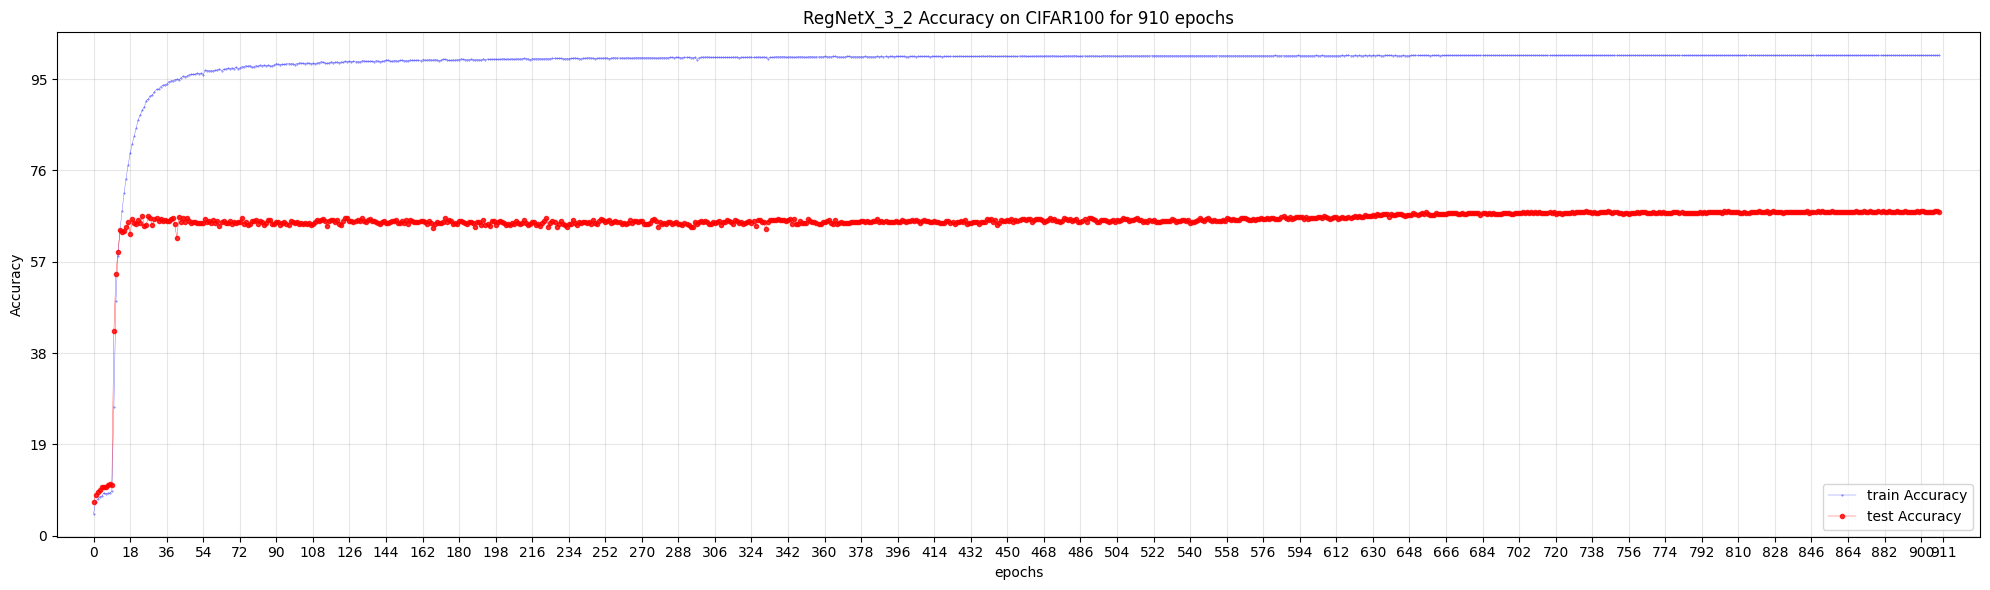

In [ ]:
plot_metric(
    train_accs_frozen + train_accs_unfrozen, 
    test_accs_frozen + test_accs_unfrozen, 
    epochs_finetune_frozen + epochs_finetune_unfrozen, 
    model_name=regnetx_3_2_name, 
    dataset_name=dataset_name, 
    metric_name="Accuracy", 
    graph_dir=graph_dir
)